In [1]:
#pip install nsepy

In [2]:
#pip install pandas

In [3]:
from Descriptive import Descriptive

In [4]:
obj=Descriptive()

In [5]:
#pip install yfinance

In [11]:
from nsepy import get_history as gh
import datetime as dt
import yfinance as yf
stock_symbol = "RELIANCE.NS" #NSE stocks usually end with .NS
#dowload the stock data from NSE
stk_data=yf.download(stock_symbol, start="2024-05-01", end="2025-10-09")

[*********************100%***********************]  1 of 1 completed


In [12]:
import warnings
warnings.filterwarnings('ignore')

In [13]:
stk_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 358 entries, 2024-05-02 to 2025-10-08
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   (Close, RELIANCE.NS)   358 non-null    float64
 1   (High, RELIANCE.NS)    358 non-null    float64
 2   (Low, RELIANCE.NS)     358 non-null    float64
 3   (Open, RELIANCE.NS)    358 non-null    float64
 4   (Volume, RELIANCE.NS)  358 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 16.8 KB


In [10]:
stk_data

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2024-05-02,1449.075317,1459.721831,1446.679164,1454.460329,14512646
2024-05-03,1416.913086,1457.375095,1399.275803,1453.472210,17226958
2024-05-06,1402.610596,1422.841601,1401.103743,1418.395221,7394208
2024-05-07,1384.775635,1403.820987,1375.413559,1399.102859,14517472
2024-05-08,1401.647339,1415.875659,1380.848112,1380.848112,9439002
...,...,...,...,...,...
2024-10-01,1452.283081,1475.210084,1450.300205,1467.972660,16431642
2024-10-03,1394.928467,1436.990273,1390.070396,1424.275008,37757294


In [14]:
low=stk_data["Low"]

In [15]:
dataset=stk_data
quan,qual=obj.segreQuanQual(dataset)

The Quantitative Data: [('Close', 'RELIANCE.NS'), ('High', 'RELIANCE.NS'), ('Low', 'RELIANCE.NS'), ('Open', 'RELIANCE.NS'), ('Volume', 'RELIANCE.NS')]
The Qualtitative Data []


In [16]:
des_data=obj.descriptive_Analysis(dataset,quan)

In [17]:
des_data

,"(Close, RELIANCE.NS)","(High, RELIANCE.NS)","(Low, RELIANCE.NS)","(Open, RELIANCE.NS)","(Volume, RELIANCE.NS)"
Null_count,0,0,0,0,0
NonNull_count,358,358,358,358,358
Total_Count,358,358,358,358,358
Mean,1369.043662,1381.391709,1357.660707,1369.788878,12643440.857542
Median,1385.080688,1399.612992,1372.794658,1384.43989,10966706.0
Mode,1267.255981,1161.221645,1105.304523,1122.505946,0
Std,102.464274,102.892247,102.377939,102.890608,6302248.931952
Min,1151.951782,1161.221645,1105.304523,1122.505946,0.0
Q1:25%,1268.086334,1284.023677,1259.7087,1272.250417,8456988.25
Q2:50%,1385.080688,1399.612992,1372.794658,1384.43989,10966706.0


In [20]:
des_data['Low', 'RELIANCE.NS']

Null_count                 0
NonNull_count            358
Total_Count              358
Mean             1357.660707
Median           1372.794658
Mode             1105.304523
Std               102.377939
Min              1105.304523
Q1:25%             1259.7087
Q2:50%           1372.794658
Q3:75%           1437.582576
Q4:100%          1566.607971
IQR               177.873876
1.5Rule           266.810814
Lesser            992.897886
Greater          1704.393389
Name: (Low, RELIANCE.NS), dtype: object

In [21]:
des_data['High', 'RELIANCE.NS']

Null_count                 0
NonNull_count            358
Total_Count              358
Mean             1381.391709
Median           1399.612992
Mode             1161.221645
Std               102.892247
Min              1161.221645
Q1:25%           1284.023677
Q2:50%           1399.612992
Q3:75%           1459.775455
Q4:100%          1589.630232
IQR               175.751778
1.5Rule           263.627666
Lesser           1020.396011
Greater          1723.403121
Name: (High, RELIANCE.NS), dtype: object

In [22]:
import numpy as np

In [23]:
np.percentile(dataset['Low', 'RELIANCE.NS'],99)

np.float64(1553.4861038919025)

In [24]:
np.percentile(dataset['High', 'RELIANCE.NS'],80)

np.float64(1471.557731444255)

In [25]:
def get_pdf_probability(dataset,startrange,endrange):
    from matplotlib import pyplot
    from scipy.stats import norm
    import seaborn as sns
    ax = sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green')
    pyplot.axvline(startrange,color='Red')
    pyplot.axvline(endrange,color='Red')
    # generate a sample
    sample = dataset
    # calculate parameters
    sample_mean =sample.mean()
    sample_std = sample.std()
    print('Mean=%.3f, Standard Deviation=%.3f' % (sample_mean, sample_std))
    # define the distribution
    dist = norm(sample_mean, sample_std)
    
    # sample probabilities for a range of outcomes
    values = [value for value in range(startrange, endrange)]
    probabilities = [dist.pdf(value) for value in values]    
    prob=sum(probabilities)
    print("The area between range({},{}):{}".format(startrange,endrange,sum(probabilities)))
    return prob
    

Mean=1357.661, Standard Deviation=102.378
The area between range(1375,1520):0.37771484271807576


np.float64(0.37771484271807576)

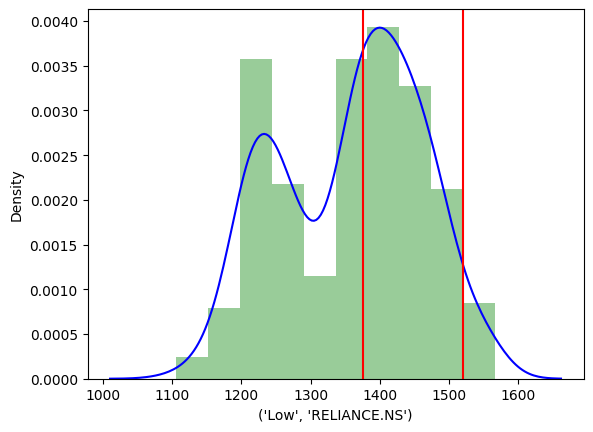

In [29]:
get_pdf_probability(dataset['Low', 'RELIANCE.NS'],1375,1520)

In [30]:
def stdNBgraph(dataset):
        # Coverted to standard Normal Distribution
    import seaborn as sns
    mean=dataset.mean()
    std=dataset.std()

    values=[i for i in dataset]

    z_score=[((j-mean)/std) for j in values]

    sns.distplot(z_score,kde=True)

    sum(z_score)/len(z_score)
    #z_score.std()

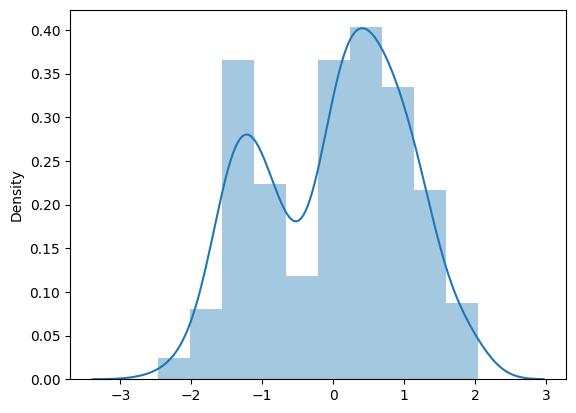

In [32]:
stdNBgraph(dataset['Low', 'RELIANCE.NS'])

In [33]:
def freqTable(columnName,dataset):
    import pandas as pd
    frq=pd.DataFrame()
    frq["Unique_Values"]=dataset[columnName].value_counts().index
    frq["Frequency"]=dataset[columnName].value_counts().values
    frq["Relative_Fre"]=dataset[columnName].value_counts().values/len(dataset[columnName])*100
    frq["Cumulative"]=frq["Relative_Fre"].cumsum()
    return frq

In [35]:
freqTable(('Low', 'RELIANCE.NS'),dataset)

,Unique_Values,Frequency,Relative_Fre,Cumulative
0,1358.220134,1,0.27933,0.279330
1,1446.679042,1,0.27933,0.558659
2,1399.275803,1,0.27933,0.837989
3,1401.103743,1,0.27933,1.117318
4,1375.413559,1,0.27933,1.396648
...,...,...,...,...
353,1381.366731,1,0.27933,98.882682
354,1396.188139,1,0.27933,99.162011
355,1383.342910,1,0.27933,99.441341
356,1367.508952,1,0.27933,99.720670


In [36]:
freqTable(('High', 'RELIANCE.NS'),dataset)

,Unique_Values,Frequency,Relative_Fre,Cumulative
0,1382.607377,1,0.27933,0.279330
1,1459.721708,1,0.27933,0.558659
2,1457.375095,1,0.27933,0.837989
3,1422.841601,1,0.27933,1.117318
4,1403.820987,1,0.27933,1.396648
...,...,...,...,...
353,1410.490494,1,0.27933,98.882682
354,1412.936124,1,0.27933,99.162011
355,1410.070522,1,0.27933,99.441341
356,1390.210169,1,0.27933,99.720670


In [37]:
fh=freqTable(('High', 'RELIANCE.NS'),dataset)

In [38]:
fh.sort_values(by="Frequency",ascending=False)

,Unique_Values,Frequency,Relative_Fre,Cumulative
357,1393.199054,1,0.27933,100.000000
0,1382.607377,1,0.27933,0.279330
1,1459.721708,1,0.27933,0.558659
2,1457.375095,1,0.27933,0.837989
3,1422.841601,1,0.27933,1.117318
...,...,...,...,...
10,1374.843199,1,0.27933,3.072626
9,1382.109671,1,0.27933,2.793296
8,1379.123542,1,0.27933,2.513966
7,1389.873900,1,0.27933,2.234637


In [41]:
fhs=fh[fh["Frequency"]==1]["Unique_Values"].sort_values(ascending=False)

In [42]:
fhs

46     1589.630232
41     1586.715466
42     1586.023756
43     1585.134442
45     1581.429189
          ...     
242    1186.354735
241    1179.613022
200    1172.871212
201    1163.948157
243    1161.221645
Name: Unique_Values, Length: 358, dtype: float64